In [5]:
import torch 
import torch.nn.functional as F 
import matplotlib.pyplot as plt
%matplotlib inline

In [11]:
#read in all the words
words = open('data/names.txt', 'r').read().splitlines()
words[:8]

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [12]:
len(words)

32033

In [14]:
#build the vocabulary of characters and mappings to/from intergers
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i, s in enumerate(chars)}
stoi['.']= 0 
itos = {i:s for s, i in stoi.items()}
print(itos)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}


In [ ]:
# build the dataset 

block_size = 3 # context length: how many charachters do we take to predict the next one? 
#X = inputs (each input is a list of 3 char-indices)
#Y = labels (the single next chaachetr to predict)
X , Y = [], []
for w in words : 

    #print 
    #[0] * 3 → [0, 0, 0]. The starting context for each word — 
    # three "dot" tokens (index 0). Why: at the very start of 
    # a name, there are no previous characters, so you pad with
    # the . token. This is the equivalent of "name hasn't started yet."
    context = [0] * block_size
    for ch in w + '.':
        ix = stoi[ch]
        X.append(context)
        Y.append(ix)
        #print(').join(itos[i] for i in context), '--->, itos[ix])
        context = context[1:] + [ix] # crop and append

X = torch.tensor(X)
Y = torch.tensor(Y)
X,Y

(tensor([[ 0,  0,  0],
         [ 0,  0,  5],
         [ 0,  5, 13],
         ...,
         [26, 26, 25],
         [26, 25, 26],
         [25, 26, 24]]),
 tensor([ 5, 13, 13,  ..., 26, 24,  0]))

In [22]:
X.shape, X.dtype, Y.shape, Y.dtype

(torch.Size([228146, 3]), torch.int64, torch.Size([228146]), torch.int64)

In [ ]:
# build the dataset 
block_size = 3 # context length 

In [27]:
# build the datset 
block_size = 3 

def build_dataset(words):
    X, Y =[], []
    for w in words: 

        #print(w)
        context = [0] * block_size
        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            #print(''.join(itos[i] for i in context), '--->', itos[ix])
            context = context[1:] + [ix] #crop and append
    
    X = torch.tensor(X)
    Y = torch.tensor(Y)
    print(X.shape, Y.shape)
    return X,Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words)) # just a  cut point at 80% of the way through the list
n2 = int(0.9*len(words))

Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[n2:])

# words[:n1] → names 0 to 25,600 → 80% → train
# words[n1:n2] → names 25,600 to 28,800 → 10% → dev/val
# words[n2:] → names 28,800 to end → 10% → test

torch.Size([182441, 3]) torch.Size([182441])
torch.Size([22902, 3]) torch.Size([22902])
torch.Size([22803, 3]) torch.Size([22803])


In [50]:
#the embedding table (27row per charachter, 2 columns) thi 2 is  hyper parametrr
C = torch.randn((27,2))

emb = C[X]
emb.shape

torch.Size([228146, 3, 2])

In [52]:
W1 = torch.randn((6, 100))  
#takes 6 inputs, produces 100 outputs.
#Why 6 inputs? Each example has 3 characters × 2 numbers each 
# Why 100? Arbitrary —
b1 = torch.randn(100)

In [ ]:
h = torch.tanh(emb.view(-1, 6) @ W1 + b1)
# The layer needs each example as one flat 6-number row, not a 3×2 grid
# The -1 means "figure out this dimension automatically"
# tanh : Squashes each of the 100 outputs into (-1, 1)
#Adds the nonlinearity that lets the network learn complex patterns

print(h)
h.shape

tensor([[-0.9303,  1.0000, -0.9626,  ...,  0.8598, -0.9981,  0.9805],
        [ 0.0439,  0.9993, -0.9962,  ...,  0.9995, -1.0000,  0.2109],
        [ 0.9508, -0.4733,  0.7415,  ...,  0.9989, -1.0000,  0.6146],
        ...,
        [ 0.4076,  0.0908, -1.0000,  ...,  0.9827, -0.9923,  0.2103],
        [-0.8508, -0.9780,  1.0000,  ..., -1.0000,  0.8078,  0.9974],
        [ 0.8725, -1.0000, -1.0000,  ...,  0.9962,  0.9811, -1.0000]])


torch.Size([228146, 100])

In [53]:
W2 = torch.randn((100, 27))
b2 = torch.randn(27)

In [54]:
logits = h @ W2 + b2

In [58]:
logits.shape

torch.Size([228146, 27])

In [60]:
counts = logits.exp()

In [70]:
prob = counts / counts.sum(1, keepdims=True)

In [71]:
prob.shape

torch.Size([228146, 27])

In [74]:
#loss = -prob[torch.arange(32), Y].log().mean()
#loss

# ------- RESPECTABLE VERSION --------

In [75]:
Xtr.shape, Ytr.shape #dataset

(torch.Size([182441, 3]), torch.Size([182441]))

In [76]:
g= torch.Generator().manual_seed(2147483647) # for reproducibility
C = torch.randn((27,10), generator =g) #the embedding table(10columns each embedded as 10 numbers)
W1 = torch.randn((30, 200), generator=g) #matrix of weights AND "30" cz blocksize : 3 x embedding dim 10 = 30 
b1 = torch.randn(200, generator=g) #bias vector for the 1st hidden layer 
W2 = torch.randn((200, 27), generator=g) # matrix of weights for 2nd hidden layer 
b2 = torch.randn(27, generator=g) #bias vector fo 2nd hidden layer
parameters = [C, W1, b1, W2, b2] # parameters that we gonna backprop later 

In [ ]:
sum(p.nelement() for p in parameters) # number of parameters in total 


11897

In [86]:
C.shape

torch.Size([27, 10])

In [87]:
C.nelement()  # what is does : 27 x 10 = 270 

270

In [88]:
for p in parameters: 
    p.requires_grad = True

In [ ]:
lre = torch.linspace(-3, 0, 1000) # 1000 numbers from -3 to 0 #torch.linspace(start, end, how many nmbrs)
lrs = 10**lre

In [94]:
lri = []
lossi = []
stepi = []

In [96]:
for i in range(200000):
    # minibatch construct 
    ix = torch.randint(0, Xtr.shape[0], (32,))

    # forward pass
    emb = C[Xtr[ix]] #(32, 3, 10)
    h = torch.tanh(emb.view(-1, 30) @ W1 + b1) # (32,200)
    logits = h @ W2 + b2 # (32, 27)
    loss = F.cross_entropy(logits, Ytr[ix])
    #print(loss.item)

    #backward pass
    for p in parameters: 
        p.grad = None
    loss.backward()

    #update
    #lr = lrs[i] why is this commented 
    lr = 0.1 if i < 100000 else 0.01
    for p in parameters: 
        p.data += -lr * p.grad
    
    #track stats 
    #lri.append(lre[i])
    stepi.append(i)
    lossi.append(loss.log10().item())

print(loss.item())

2.3188302516937256


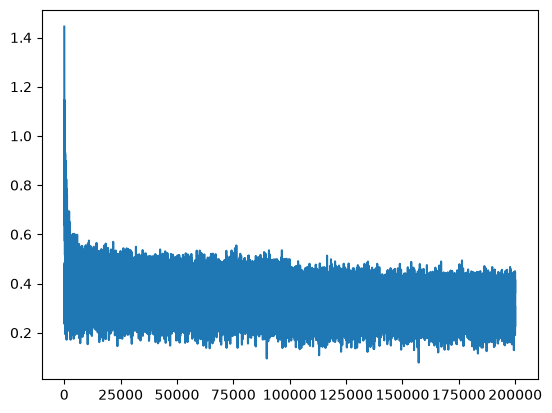

In [98]:
plt.plot(stepi, lossi)

In [101]:
emb = C[Xtr] #(32, 3 , 2 )
h = torch.tanh(emb.view(-1, 30) @ W1 + b1) #32,100 
logits = h @ W2 + b2 # (32, 27)
loss = F.cross_entropy(logits, Ytr)
loss

tensor(2.0809, grad_fn=<NllLossBackward0>)

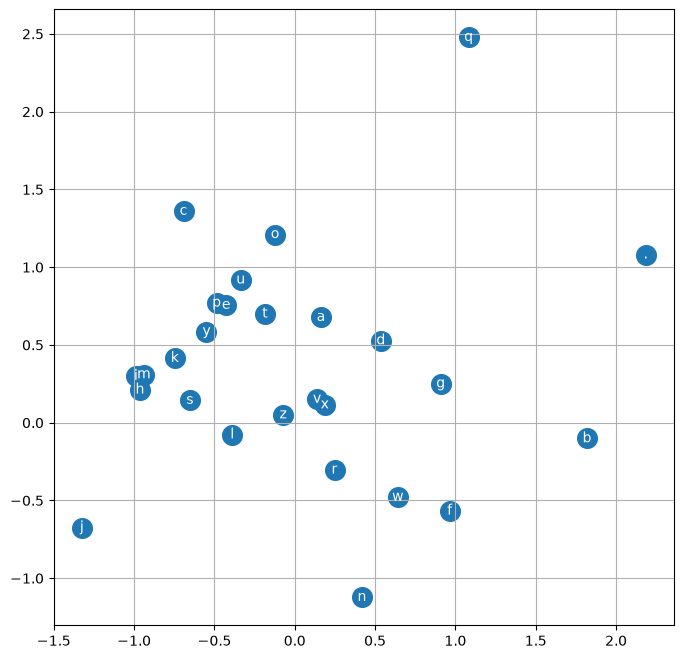

In [104]:
# visualize dimensions 0 and 1 of the embedding matrix C for all characters
plt.figure(figsize=(8,8))
plt.scatter(C[:,0].data, C[:,1].data, s=200)
for i in range(C.shape[0]):
    plt.text(C[i,0].item(), C[i,1].item(), itos[i], ha="center", va="center", color='white')
plt.grid('minor')

In [ ]:
#training split, dev/validation split, test split 
#80%             10%                   10%

In [105]:
context = [0] * block_size
C[torch.tensor([context])].shape

torch.Size([1, 3, 10])

In [106]:
#sample from the model 
g= torch.Generator().manual_seed(2147483647 + 10)

for _ in range(20) : 

    out = []
    context = [0] * block_size # initialize with all.. 
    while True: 
        emb = C[torch.tensor([context])] # (1, block_size, d)
        h = torch.tanh(emb.view(1, -1) @ W1 + b1)
        logits = h @ W2 + b2
        probs = F.softmax(logits, dim  =1)
        ix = torch.multinomial(probs, num_samples=1, generator=g).item()
        context = context[1:] + [ix]
        out.append(ix)
        if ix == 0: 
            break 
    
    print(''.join(itos[i] for i in out))

carmah.
quille.
khi.
mili.
thil.
skaadane.
rahnee.
deliah.
jareen.
ner.
kia.
chrian.
kaleigh.
ham.
prin.
quint.
shoil.
alianni.
watell.
dearinix.
